In [1]:
# import modules
import scipy.integrate
import pyfabm
from matplotlib.pyplot import figure
import pandas as pd
import xarray as xr
from numpy import zeros

# define function to calculate derivative / growth rates
def dy(t, y):
    model.state[:] = y
    return model.getRates(t)

In [3]:
# load inputs - these would be the EO derived information, they can be at different temporal resolution
input_T_timeseries=xr.open_dataset('./T_daily_timeseries.nc')
input_S_timeseries=xr.open_dataset('./S_daily_timeseries.nc')
input_Chl_timeseries=xr.open_dataset('./Chl_monthly_timeseries.nc')
input_POC_timeseries=xr.open_dataset('./POC_monthly_timeseries.nc')
input_POM_timeseries=xr.open_dataset('./POM_monthly_timeseries.nc')
input_TPM_timeseries=xr.open_dataset('./TPM_monthly_timeseries.nc')

In [5]:
print(input_T_timeseries)

<xarray.Dataset> Size: 6kB
Dimensions:      (time: 365)
Coordinates:
  * time         (time) datetime64[ns] 3kB 2010-01-01 2010-01-02 ... 2010-12-31
Data variables:
    temperature  (time) float64 3kB ...


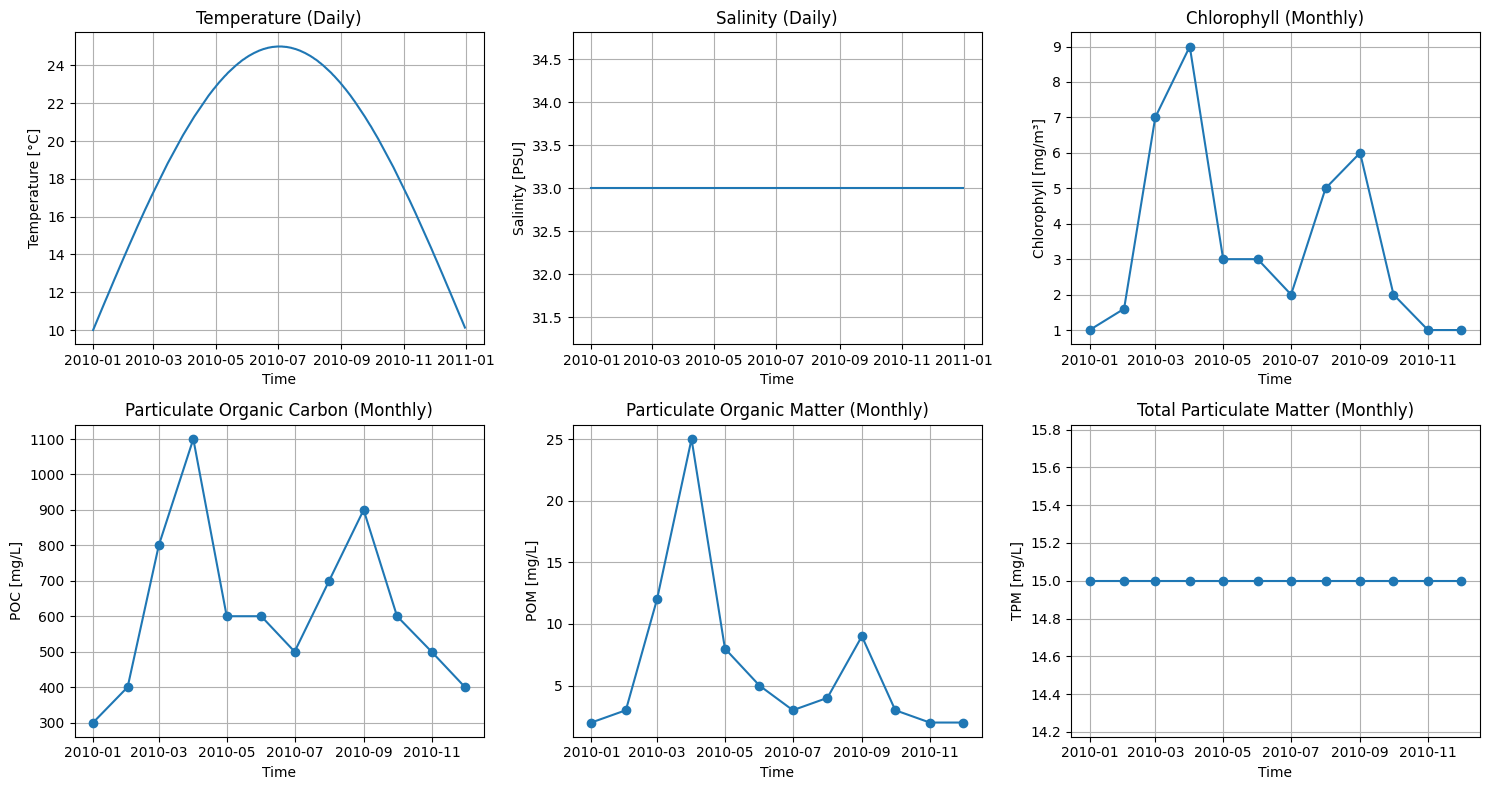

In [6]:
# Create a figure with 2 rows and 3 columns to visualize all input timeseries
fig = figure(figsize=(15, 8))

# Plot Temperature
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(input_T_timeseries.time, input_T_timeseries.temperature)
ax1.set_xlabel('Time')
ax1.set_ylabel('Temperature [°C]')
ax1.set_title('Temperature (Daily)')
ax1.grid(True)

# Plot Salinity
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(input_S_timeseries.time, input_S_timeseries.salinity)
ax2.set_xlabel('Time')
ax2.set_ylabel('Salinity [PSU]')
ax2.set_title('Salinity (Daily)')
ax2.grid(True)

# Plot Chlorophyll
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(input_Chl_timeseries.time, input_Chl_timeseries.Chl, 'o-')
ax3.set_xlabel('Time')
ax3.set_ylabel('Chlorophyll [mg/m³]')
ax3.set_title('Chlorophyll (Monthly)')
ax3.grid(True)

# Plot POC
ax4 = fig.add_subplot(2, 3, 4)
ax4.plot(input_POC_timeseries.time, input_POC_timeseries.POC, 'o-')
ax4.set_xlabel('Time')
ax4.set_ylabel('POC [mg/L]')
ax4.set_title('Particulate Organic Carbon (Monthly)')
ax4.grid(True)

# Plot POM
ax5 = fig.add_subplot(2, 3, 5)
ax5.plot(input_POM_timeseries.time, input_POM_timeseries.POM, 'o-')
ax5.set_xlabel('Time')
ax5.set_ylabel('POM [mg/L]')
ax5.set_title('Particulate Organic Matter (Monthly)')
ax5.grid(True)

# Plot TPM
ax6 = fig.add_subplot(2, 3, 6)
ax6.plot(input_TPM_timeseries.time, input_TPM_timeseries.TPM, 'o-')
ax6.set_xlabel('Time')
ax6.set_ylabel('TPM [mg/L]')
ax6.set_title('Total Particulate Matter (Monthly)')
ax6.grid(True)

fig.tight_layout()

In [3]:


# set-up of the model
model = pyfabm.Model("fabm.yaml")

# set-up of external dependencies
model.cell_thickness = 1.0  # cell thickness in m, used by getRates to scale surface and bottom fluxes
model.dependencies["seeding_rate"].value=0.0
model.dependencies["harvest_ratio"].value=0.0
model.dependencies["temperature"].value=20.0
model.dependencies["practical_salinity"].value=33.0
model.dependencies["current_speed"].value=1.0
model.dependencies["harvest_ratio"].value=0.0
model.dependencies["air_exposure"].value=0.0
model.dependencies["number_of_days_since_start_of_the_year"].value=0.0

# checkl that model is set up correctly
assert model.start(), f"Model failed to start: {pyfabm.getError()}"


# integrate the model
# result dimensions are time x variables
# variables are:
# shell energy
# dry soft tissue energy
# aging
# individuals in size class 1
# individuals in size class 2
# individuals in size class 3


Initializing Oyster...
   model type: shellsim_base
   initialization succeeded.
Initializing Chl1...
   model type: shellsim/prey
   initialization succeeded.
Initializing POC1...
   model type: shellsim/prey
   initialization succeeded.
Initializing POM1...
   model type: shellsim/prey
   initialization succeeded.
Initializing TPM1...
   model type: shellsim/prey
   initialization succeeded.
Initializing O2...
   model type: bb/passive
   initialization succeeded.


Text(0.5, 1.0, 'Oyster - Shell Length')

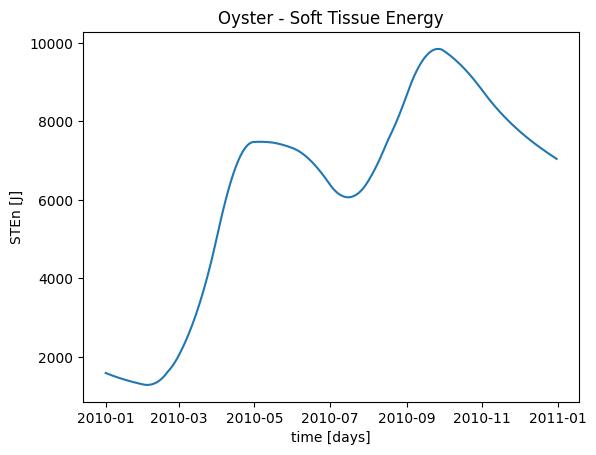

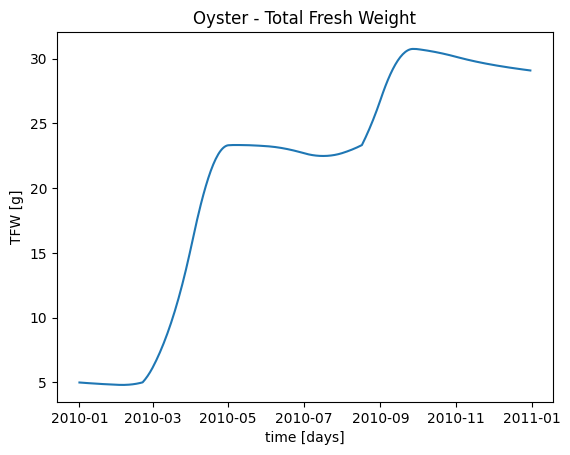

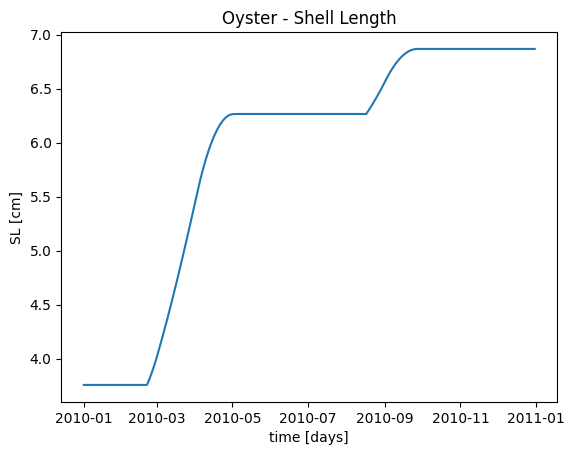

In [7]:



#define period of integration - timestep = 1day
start='1-1-2010'
end='31-12-2010'
time_horizon=pd.date_range(start=start,end=end,freq='1d')

# make sure that all timeseries have the same (daily) resolution.
T_timeseries=input_T_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
S_timeseries=input_S_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
Chl_timeseries=input_Chl_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
POC_timeseries=input_POC_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
POM_timeseries=input_POM_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})
TPM_timeseries=input_TPM_timeseries.interp(time=time_horizon,kwargs={'fill_value':'extrapolate'})

# initialise array with outputs
outputs=zeros((11,time_horizon.size))
# output 0:  Soft tissue energy
# output 1:  Shell energy
# output 2:  aging
# output 3:  C1
# output 4:  C2
# output 5:  C3
# output 6:  Chl
# output 7:  POC
# output 8:  POM
# output 9:  TPM
# output 10: O2

# initialise arrays for the diagnostics Total Fresh Weight (TFW) and Shell Length (SL)
TFW=zeros((time_horizon.size))
SL=zeros((time_horizon.size))

# daily integration over the temporal horizon
for nd,day in enumerate(time_horizon):
    # set the right environmental variables
    model.dependencies["temperature"].value=T_timeseries.temperature.sel(time=day,method='nearest').values
    model.dependencies["practical_salinity"].value=S_timeseries.salinity.sel(time=day,method='nearest').values

    # set the right food variables
    model.findStateVariable('Chl1/Chl').value=Chl_timeseries.Chl.sel(time=day,method='nearest').values
    model.findStateVariable('POC1/POC').value=POC_timeseries.POC.sel(time=day,method='nearest').values
    model.findStateVariable('POM1/POM').value=POM_timeseries.POM.sel(time=day,method='nearest').values
    model.findStateVariable('TPM1/TPM').value=TPM_timeseries.TPM.sel(time=day,method='nearest').values

    # calculate growth rates
    state_rates=model.getRates()

    # perform forward Euler integration
    model.state[:]+=state_rates*86400.

    # save the integrated values in the outputs
    outputs[:,nd]=model.state[:]

    # save the diagnostics
    TFW[nd]=model.diagnostic_variables['Oyster/TFW'].value
    SL[nd]=model.diagnostic_variables['Oyster/Shell_Length'].value



fig=figure()
ax=fig.add_subplot()
ax.plot(time_horizon,outputs[0,:],label='Soft Tissue Energy')
ax.set_xlabel('time [days]')
ax.set_ylabel('STEn [J]')
ax.set_title('Oyster - Soft Tissue Energy')


fig=figure()
ax=fig.add_subplot()
ax.plot(time_horizon,TFW,label='Total Fresh Weight')
ax.set_xlabel('time [days]')
ax.set_ylabel('TFW [g]')
ax.set_title('Oyster - Total Fresh Weight')


fig=figure()
ax=fig.add_subplot()
ax.plot(time_horizon,SL,label='Shell Length')
ax.set_xlabel('time [days]')
ax.set_ylabel('SL [cm]')
ax.set_title('Oyster - Shell Length')